##0. Импорты и загрузка данных

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression, LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
df = pd.read_csv("/content/weatherAUS.csv")

In [3]:
df.shape

(145460, 23)

##1. EDA

In [4]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


В данных присуствует временная метка формата ymd, преобразуем ее в 4 признака winter, spring, summer, autumn (то есть one hot кодирование времени года)

In [5]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['Season'] = df['Month'].apply(get_season)
season_dummies = pd.get_dummies(df['Season'], dtype=int)
df = pd.concat([df, season_dummies], axis=1)

df.drop(['Date', 'Month', 'Season'], axis=1, inplace=True)
df.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Autumn,Spring,Summer,Winter
0,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,...,8.0,NaN,16.9,21.8,No,No,0,0,0,1
1,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,...,NaN,NaN,17.2,24.3,No,No,0,0,0,1
2,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,...,NaN,2.0,21.0,23.2,No,No,0,0,0,1
3,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,...,NaN,NaN,18.1,26.5,No,No,0,0,0,1
4,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,...,7.0,8.0,17.8,29.7,No,No,0,0,0,1


In [6]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,Autumn,Spring,Summer,Winter
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000,145460.000000,145460.000000,145460.000000,145460.000000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339,0.242933,0.263055,0.252557,0.241455
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665,0.428856,0.440294,0.434481,0.427967
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000,0.000000,0.000000,0.000000,0.000000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000,0.000000,0.000000,0.000000,0.000000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000,0.000000,0.000000,0.000000,0.000000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000,0.000000,1.000000,1.000000,0.000000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000,1.000000,1.000000,1.000000,1.000000


На первый взгляд в данных нет каких-либо выбросов или иных странностей

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 26 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Location       145460 non-null  object 
 1   MinTemp        143975 non-null  float64
 2   MaxTemp        144199 non-null  float64
 3   Rainfall       142199 non-null  float64
 4   Evaporation    82670 non-null   float64
 5   Sunshine       75625 non-null   float64
 6   WindGustDir    135134 non-null  object 
 7   WindGustSpeed  135197 non-null  float64
 8   WindDir9am     134894 non-null  object 
 9   WindDir3pm     141232 non-null  object 
 10  WindSpeed9am   143693 non-null  float64
 11  WindSpeed3pm   142398 non-null  float64
 12  Humidity9am    142806 non-null  float64
 13  Humidity3pm    140953 non-null  float64
 14  Pressure9am    130395 non-null  float64
 15  Pressure3pm    130432 non-null  float64
 16  Cloud9am       89572 non-null   float64
 17  Cloud3pm       86102 non-null

In [8]:
df.isnull().sum()

,0
Location,0
MinTemp,1485
MaxTemp,1261
Rainfall,3261
Evaporation,62790
Sunshine,69835
WindGustDir,10326
WindGustSpeed,10263
WindDir9am,10566
WindDir3pm,4228


У некоторых признаков отствует вплоть до половины значений

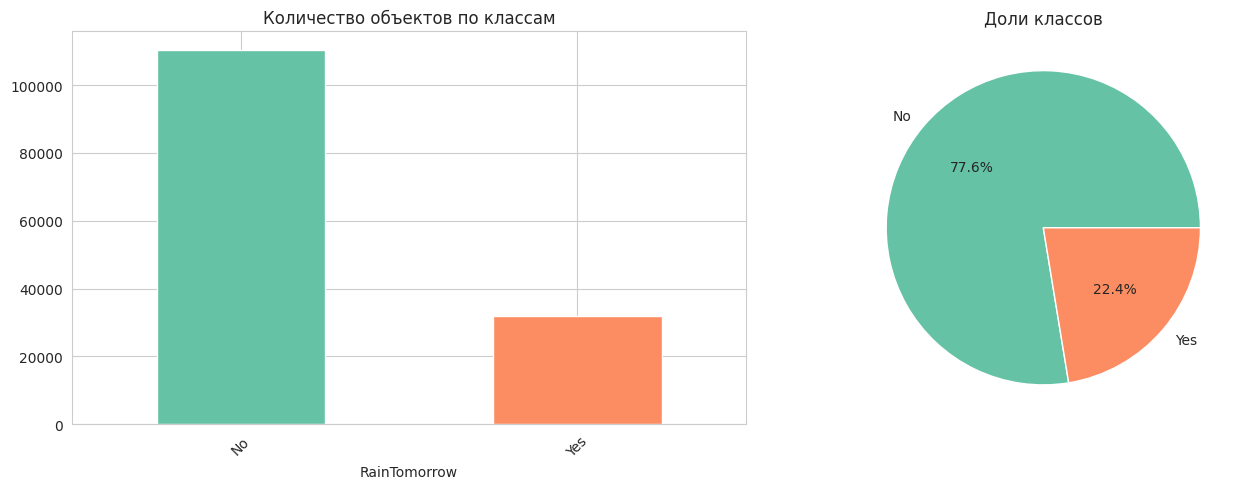

In [9]:
target = 'RainTomorrow'
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[target].value_counts().plot.bar(ax=axes[0], color=sns.color_palette('Set2'))
axes[0].set_title('Количество объектов по классам')
axes[0].tick_params(axis='x', rotation=45)

df[target].value_counts(normalize=True).plot.pie(ax=axes[1], autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[1].set_ylabel('')
axes[1].set_title('Доли классов')
plt.tight_layout()
plt.show()

Классы плохо сбалансированы

Будем предсказывать класс RainTomorrow, поэтому необходимо посмотреть сохранит ли таргет распределение при удалении пропусков

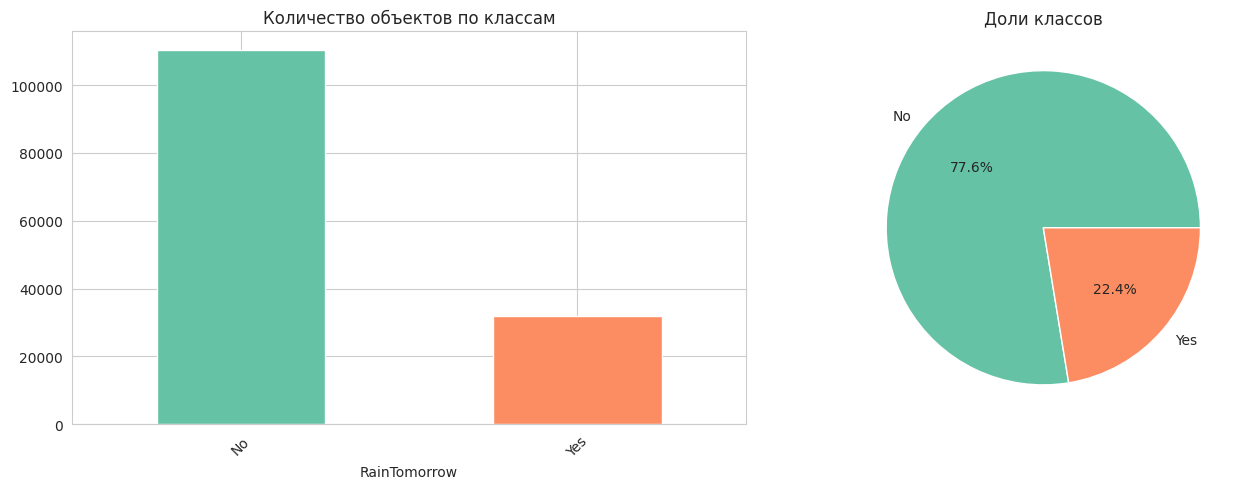

In [10]:
df = df.dropna(subset=[target])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[target].value_counts().plot.bar(ax=axes[0], color=sns.color_palette('Set2'))
axes[0].set_title('Количество объектов по классам')
axes[0].tick_params(axis='x', rotation=45)

df[target].value_counts(normalize=True).plot.pie(ax=axes[1], autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[1].set_ylabel('')
axes[1].set_title('Доли классов')
plt.tight_layout()
plt.show()

Распределение осталось тем же, посмотрим как изменилось количество пропусков по другим признакам

In [11]:
df.isnull().sum()

,0
Location,0
MinTemp,637
MaxTemp,322
Rainfall,1406
Evaporation,60843
Sunshine,67816
WindGustDir,9330
WindGustSpeed,9270
WindDir9am,10013
WindDir3pm,3778


Стало чуть получше, но у некоторых признаков все еще нет половины значений

###1.1. Числовые признаки

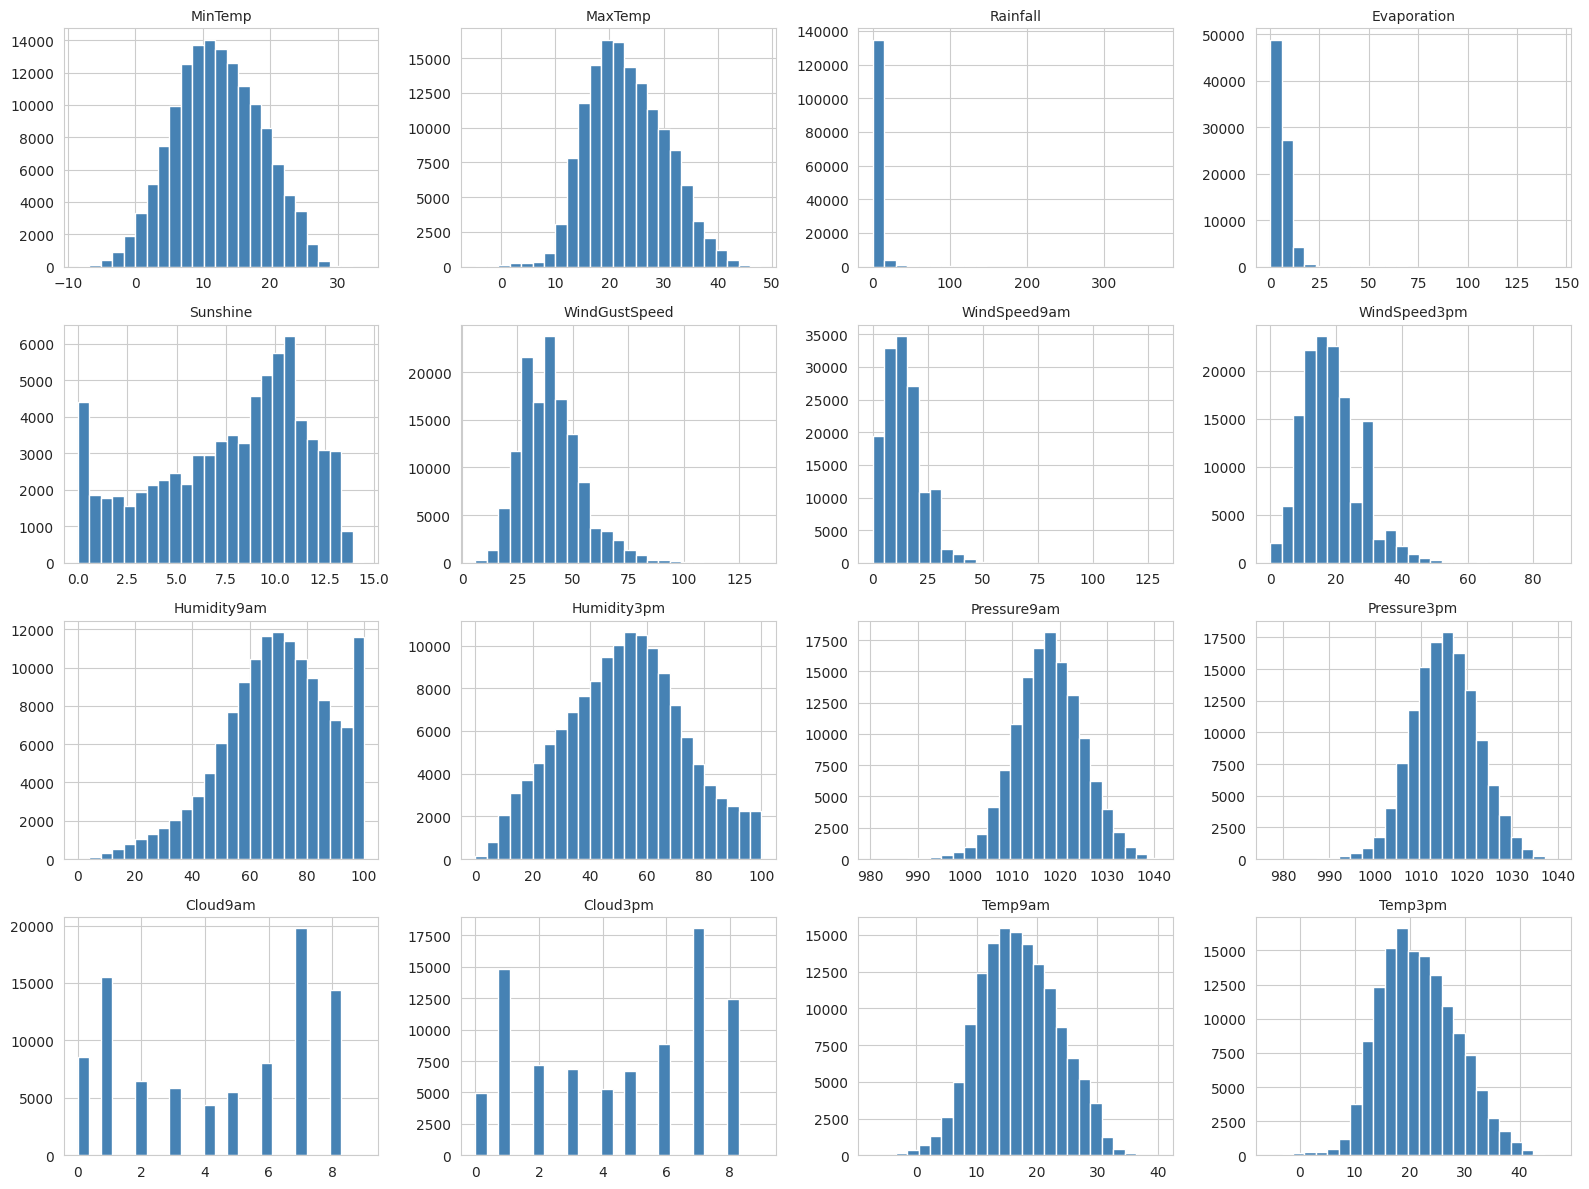

In [12]:
numeric_cols = df.select_dtypes(include=np.number).drop(columns=['Autumn', 'Spring', 'Summer', 'Winter']).columns.tolist()

n_cols = 4
n_rows = 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df[col].hist(bins=25, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Некоторые признаки распределены почти нормально

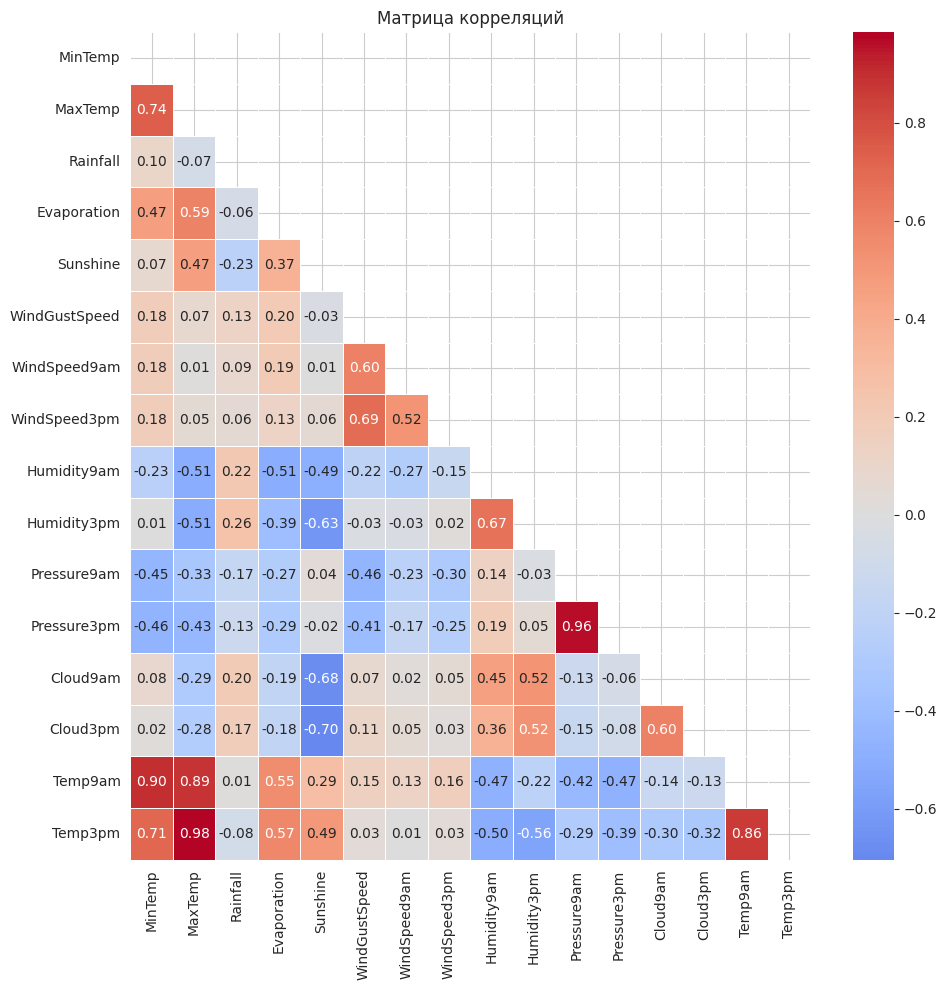

In [13]:
plt.figure(figsize=(10, 10))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Матрица корреляций')
plt.tight_layout()
plt.show()

Сильно скоррелированы следующие пары:  
pressure9am - pressure3pm  
maxtemp - temp3pm  
mintemp - temp9am  
maxtemp - mintemp  
temp9am - temp3pm  
Все эти корреляции вполне согласуются с физическими соображениями

###1.2. Категориальные признаки

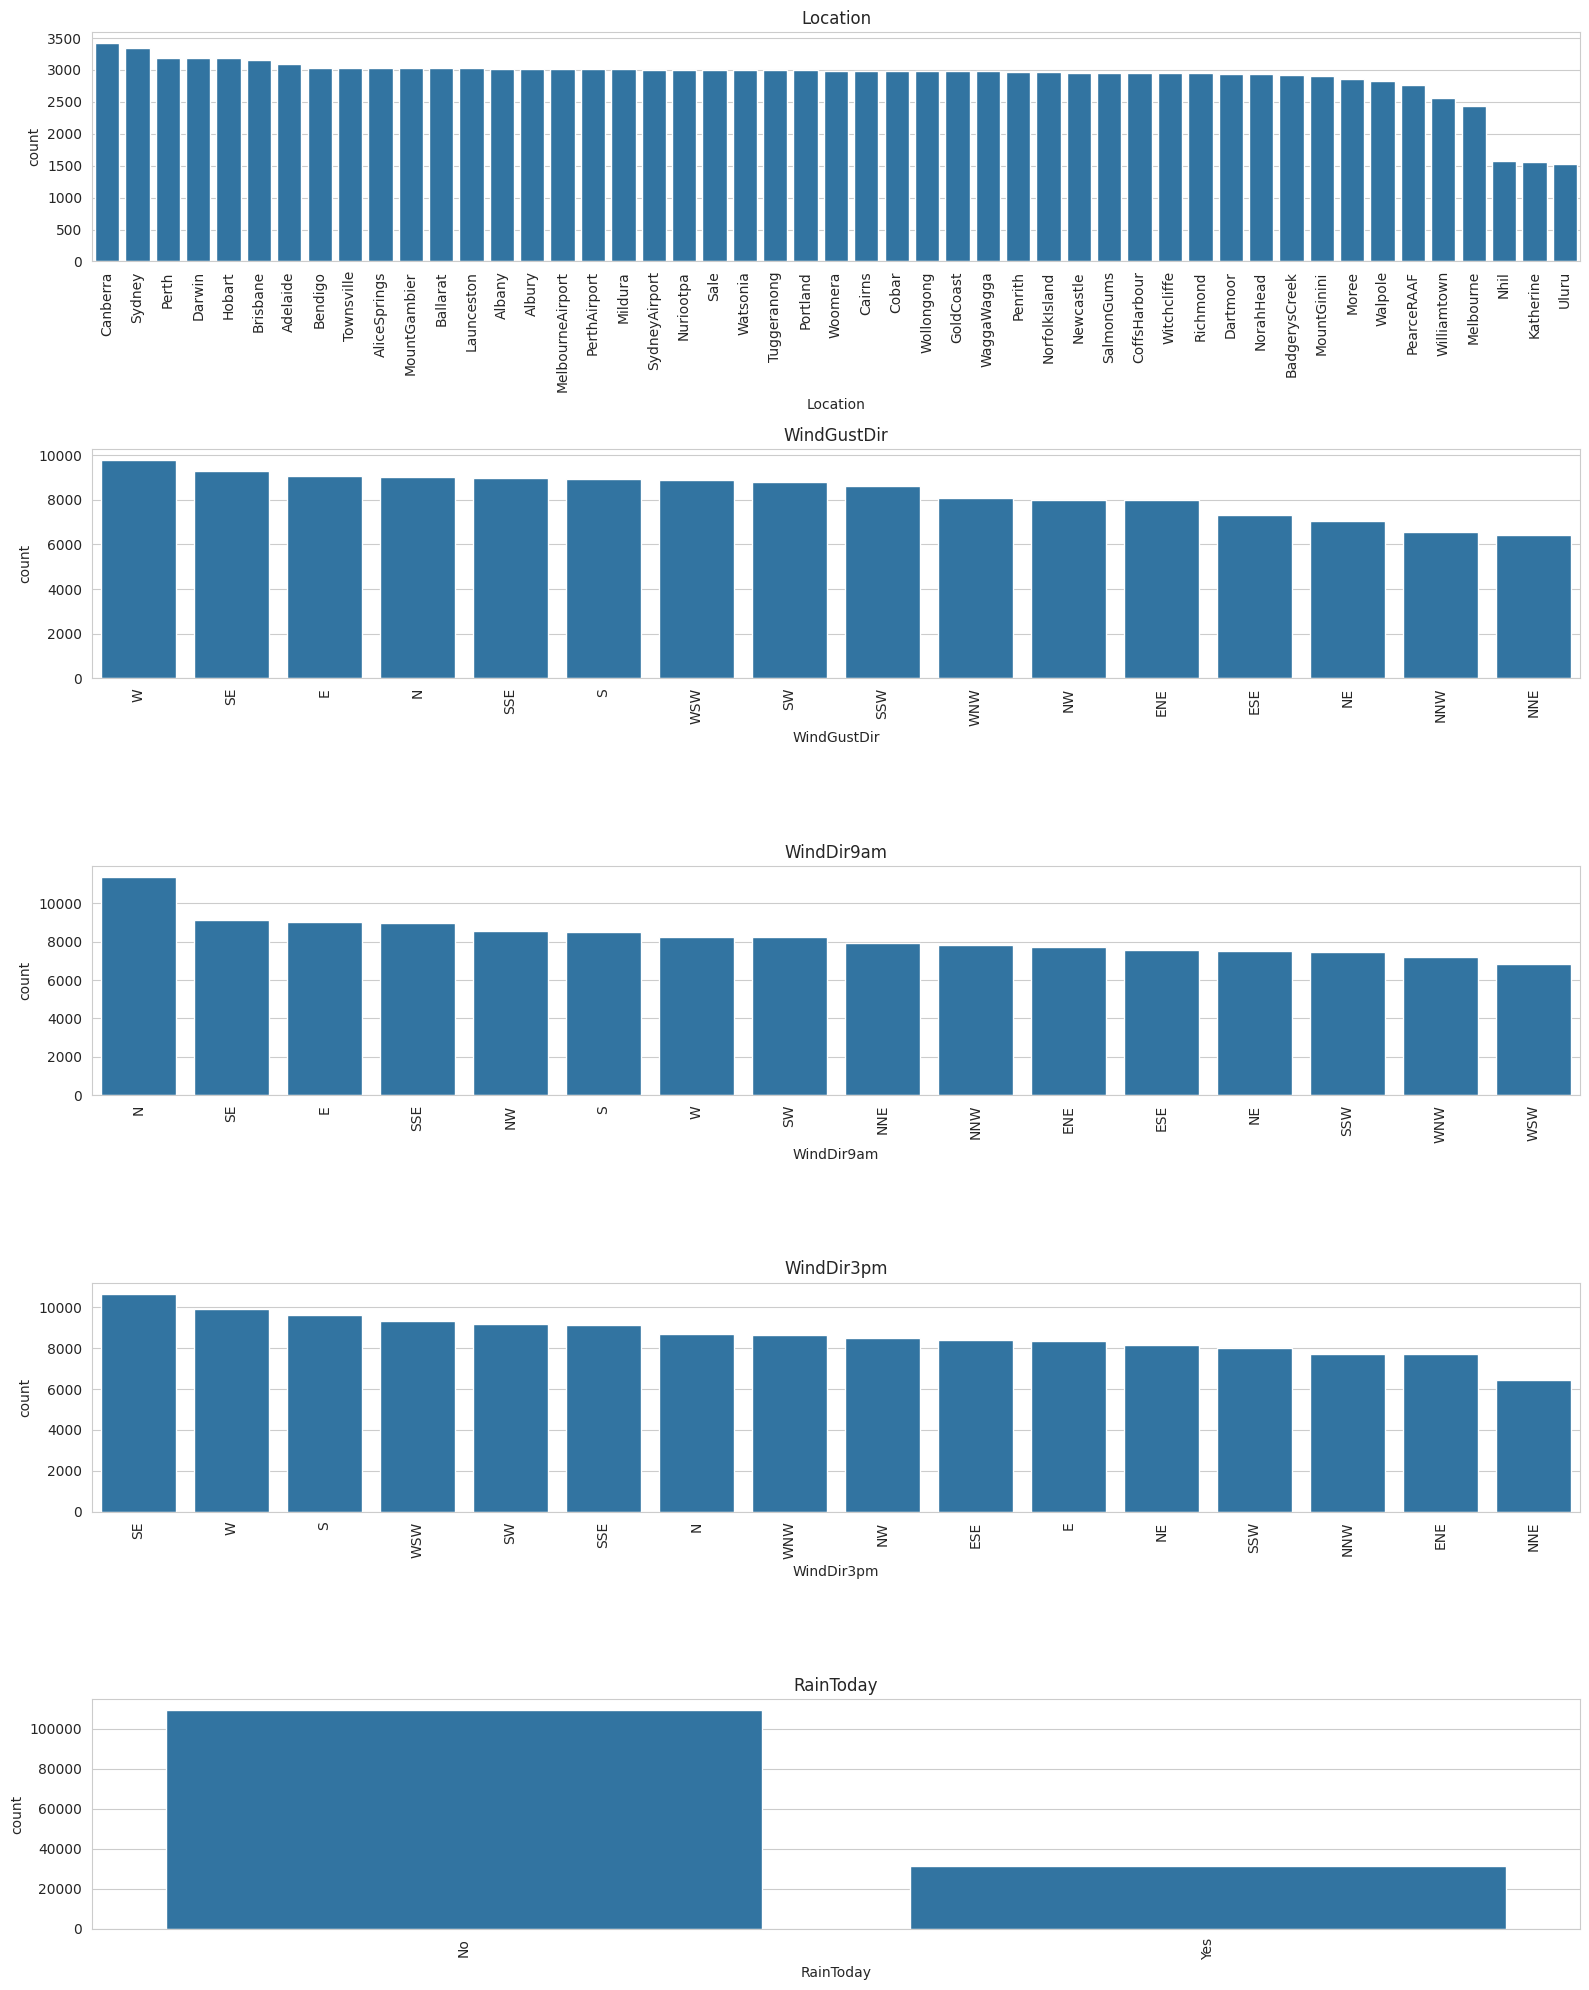

In [14]:
categorical_cols = df.select_dtypes(include=object).columns.tolist()

categorical_cols = [col for col in categorical_cols if col not in ['RainTomorrow']]

n_cols = 1
n_rows = 5

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

In [15]:
df.drop(['MaxTemp', 'MinTemp', 'Pressure9am', 'WindDir9am'], axis=1, inplace=True)

In [16]:
df.shape

(142193, 22)

##2. Регрессия и классификация

В данных слишком много пропусков, чтобы их можно было выбросить. Поэтому пропуски в числовых признаках заполним средним, в категориальных - модой и затем проведем one-hot кодирование

Для начала попробуем предсказывать RainTomorrow с помощью логистической регрессии и рещающего дерева, также попробуем добавить в пайплайнстандартизацию числовых признаков

In [17]:
df['RainToday'] = df['RainToday'].replace({'No': 0, 'Yes': 1})
df['RainTomorrow'] = df['RainTomorrow'].replace({'No': 0, 'Yes': 1})
df.head()

,Location,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,...,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Autumn,Spring,Summer,Winter
0,Albury,0.6,NaN,NaN,W,44.0,WNW,20.0,24.0,71.0,...,8.0,NaN,16.9,21.8,0.0,0,0,0,0,1
1,Albury,0.0,NaN,NaN,WNW,44.0,WSW,4.0,22.0,44.0,...,NaN,NaN,17.2,24.3,0.0,0,0,0,0,1
2,Albury,0.0,NaN,NaN,WSW,46.0,WSW,19.0,26.0,38.0,...,NaN,2.0,21.0,23.2,0.0,0,0,0,0,1
3,Albury,0.0,NaN,NaN,NE,24.0,E,11.0,9.0,45.0,...,NaN,NaN,18.1,26.5,0.0,0,0,0,0,1
4,Albury,1.0,NaN,NaN,W,41.0,NW,7.0,20.0,82.0,...,7.0,8.0,17.8,29.7,0.0,0,0,0,0,1


Создадим два набора данных - для классификации и для регресии

In [18]:
X_1 = df.drop(columns=['RainTomorrow'])
y_1 = df['RainTomorrow']

df2 = df.dropna(subset=['Temp3pm'])
X_2 = df2.drop(columns=['Temp3pm'])
y_2 = df2['Temp3pm']

X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_1, y_1, test_size=0.25, stratify=y_1, random_state=0)
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, test_size=0.25, random_state=0)

In [19]:
num_cols1 = X_train_1.select_dtypes(include=np.number).columns.tolist()
cat_cols1 = X_train_1.select_dtypes(include=object).columns.tolist()

num_cols2 = X_train_2.select_dtypes(include=np.number).columns.tolist()
cat_cols2 = X_train_2.select_dtypes(include=object).columns.tolist()

numeric_scale = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

numeric = Pipeline([
    ('imputer', SimpleImputer(strategy='mean'))
])

cat = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [20]:
preprocessor1 = ColumnTransformer(
    transformers=[
        ('num', numeric, num_cols1),
        ('cat', cat, cat_cols1)
    ])
preprocessor1_scale = ColumnTransformer(
    transformers=[
        ('num', numeric_scale, num_cols1),
        ('cat', cat, cat_cols1)
    ])

In [21]:
preprocessor2 = ColumnTransformer(
    transformers=[
        ('num', numeric, num_cols2),
        ('cat', cat, cat_cols2)
    ])
preprocessor2_scale = ColumnTransformer(
    transformers=[
        ('num', numeric_scale, num_cols2),
        ('cat', cat, cat_cols2)
    ])

###3.1. Классификация

В качестве бейзлайна возьмем простую логистическую регрессию. После этого попробуем добавить к ней стандартизацию числовых признаков

In [22]:
lr_no_scale = Pipeline([
    ('prep', preprocessor1),
    ('clf', LogisticRegression(max_iter=1000, random_state=0))
])

lr_scale = Pipeline([
    ('prep', preprocessor1_scale),
    ('clf', LogisticRegression(max_iter=1000, random_state=0))
])

Логистическая регрессия

In [23]:
lr_no_scale.fit(X_train_1, y_train_1)
y_pred_lr_no_scale = lr_no_scale.predict(X_test_1)

print('Accuracy :', accuracy_score(y_test_1, y_pred_lr_no_scale))
print('Precision :', precision_score(y_test_1, y_pred_lr_no_scale, zero_division=0))
print('Recall :', recall_score(y_test_1, y_pred_lr_no_scale, zero_division=0))
print('F1 :', f1_score(y_test_1, y_pred_lr_no_scale, zero_division=0))

Accuracy : 0.8448620214352022
Precision : 0.7245607613469985
Recall : 0.4968001003890074
F1 : 0.5894439067966947


Логистическая регрессия с стандартизацией

In [24]:
lr_scale.fit(X_train_1, y_train_1)
y_pred_lr_scale = lr_scale.predict(X_test_1)

print('Accuracy :', accuracy_score(y_test_1, y_pred_lr_scale))
print('Precision :', precision_score(y_test_1, y_pred_lr_scale, zero_division=0))
print('Recall :', recall_score(y_test_1, y_pred_lr_scale, zero_division=0))
print('F1 :', f1_score(y_test_1, y_pred_lr_scale, zero_division=0))

Accuracy : 0.8467186137444092
Precision : 0.724119530416222
Recall : 0.5108545614255239
F1 : 0.599072915900228


Видно, что добавление стандартизации существенно не повлияло на качество классификации

Теперь попробуем использовать для той же задачи решающие деревья.
Для решающих деревьев масштаб признаков неважен, проверим это на практике.

In [25]:
dt_no_scale = Pipeline([
    ('prep', preprocessor1),
    ('clf', DecisionTreeClassifier(random_state=0))
])

dt_scale = Pipeline([
    ('prep', preprocessor1_scale),
    ('clf', DecisionTreeClassifier(random_state=0))
])

Решающее дерево

In [26]:
dt_no_scale.fit(X_train_1, y_train_1)
y_pred_dt_no_scale = dt_no_scale.predict(X_test_1)

print('Accuracy :', accuracy_score(y_test_1, y_pred_dt_no_scale))
print('Precision :', precision_score(y_test_1, y_pred_dt_no_scale, zero_division=0))
print('Recall :', recall_score(y_test_1, y_pred_dt_no_scale, zero_division=0))
print('F1 :', f1_score(y_test_1, y_pred_dt_no_scale, zero_division=0))

Accuracy : 0.7897549860755577
Precision : 0.5302087147564994
Recall : 0.5451123102020329
F1 : 0.5375572330157159


Решающее дерево со стандартизацией

In [27]:
dt_scale.fit(X_train_1, y_train_1)
y_pred_dt_scale = dt_scale.predict(X_test_1)

print('Accuracy :', accuracy_score(y_test_1, y_pred_dt_scale))
print('Precision :', precision_score(y_test_1, y_pred_dt_scale, zero_division=0))
print('Recall :', recall_score(y_test_1, y_pred_dt_scale, zero_division=0))
print('F1 :', f1_score(y_test_1, y_pred_dt_scale, zero_division=0))

Accuracy : 0.7895862049565389
Precision : 0.5297843829942745
Recall : 0.545739741498306
F1 : 0.5376437136852515


Действительно, метрики качества почти не изменились

А теперь попробуем с помощью кросс-валидации и поиска по сетке подобрать гиперпараметры для дерева

In [28]:
param_grid = {
    'clf__max_depth': [None, 3, 5, 7, 10],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__criterion': ['gini', 'entropy']
}

dt_pipeline = Pipeline([
    ('prep', preprocessor1),
    ('clf', DecisionTreeClassifier(random_state=0))
])

grid_search = GridSearchCV(
    dt_pipeline,
    param_grid,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_1, y_train_1)
print(grid_search.best_params_)
print(grid_search.best_score_)

Fitting 5 folds for each of 90 candidates, totalling 450 fits
{'clf__criterion': 'gini', 'clf__max_depth': 10, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2}
0.5742809352040069


In [29]:
best_dt = grid_search.best_estimator_
y_pred_best_dt = best_dt.predict(X_test_1)

print('Accuracy :', accuracy_score(y_test_1, y_pred_best_dt))
print('Precision :', precision_score(y_test_1, y_pred_best_dt, zero_division=0))
print('Recall :', recall_score(y_test_1, y_pred_best_dt, zero_division=0))
print('F1 :', f1_score(y_test_1, y_pred_best_dt, zero_division=0))

Accuracy : 0.8387015105910152
Precision : 0.701460248783126
Recall : 0.4882670347596938
F1 : 0.5757620597810003


Подбор гиперпараметров дал ощутимый прирост качества

###3.2. Регрессия

В задаче регрессии будем предсказывать признак Temp3pm.  
В качестве бейзлайна возьмем обычную линейную модель с стандартизацией признаков

In [30]:
linear_scale = Pipeline([
    ('prep', preprocessor2_scale),
    ('regr', LinearRegression())
])

In [31]:
linear_scale.fit(X_train_2, y_train_2)
y_pred_linear_scale = linear_scale.predict(X_test_2)

print('MAE :', mean_absolute_error(y_test_2, y_pred_linear_scale))
print('MSE :', mean_squared_error(y_test_2, y_pred_linear_scale))
print('R2 :', r2_score(y_test_2, y_pred_linear_scale))

MAE : 1.3750528702607276
MSE : 3.326076325712182
R2 : 0.9299373252670939


Теперь попробуем добавить к линейной модели L1 и L2 регуляризации, штрафующие коэффициенты подберем с помощью поиска по сетке

In [32]:
lasso_scale = Pipeline([
    ('prep', preprocessor2_scale),
    ('regr', Lasso(random_state=0, max_iter=1000))
])

ridge_scale = Pipeline([
    ('prep', preprocessor2_scale),
    ('regr', Ridge(random_state=0, max_iter=1000))
])

Линейная регрессия с L1 регуляризацией

In [33]:
param_grid_lasso = {
    'regr__alpha': [0.1, 1, 10, 100]
}

grid_search_lasso = GridSearchCV(
    lasso_scale,
    param_grid_lasso,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search_lasso.fit(X_train_2, y_train_2)

print(grid_search_lasso.best_params_)
print(-grid_search_lasso.best_score_)


Fitting 5 folds for each of 4 candidates, totalling 20 fits
{'regr__alpha': 0.1}
3.915511647482995


Линейная регрессия с L2 регуляризацией

In [34]:
param_grid_ridge = {
    'regr__alpha': [0.1, 1, 10, 100]
}

grid_search_ridge = GridSearchCV(
    ridge_scale,
    param_grid_ridge,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search_ridge.fit(X_train_2, y_train_2)

print(grid_search_ridge.best_params_)
print(-grid_search_ridge.best_score_)


Fitting 5 folds for each of 4 candidates, totalling 20 fits
{'regr__alpha': 10}
3.315455101888513


Удивительно, но регуляризация ухудшила или почти не улучшила прогнозы модели. Это может быть связано с неподходящей сеткой перебора или, например, с физическими взаимосвязями признаков

В заключение, посмотрим на коэфициенты L1 регрессии, которая как раз и отбирает признаки

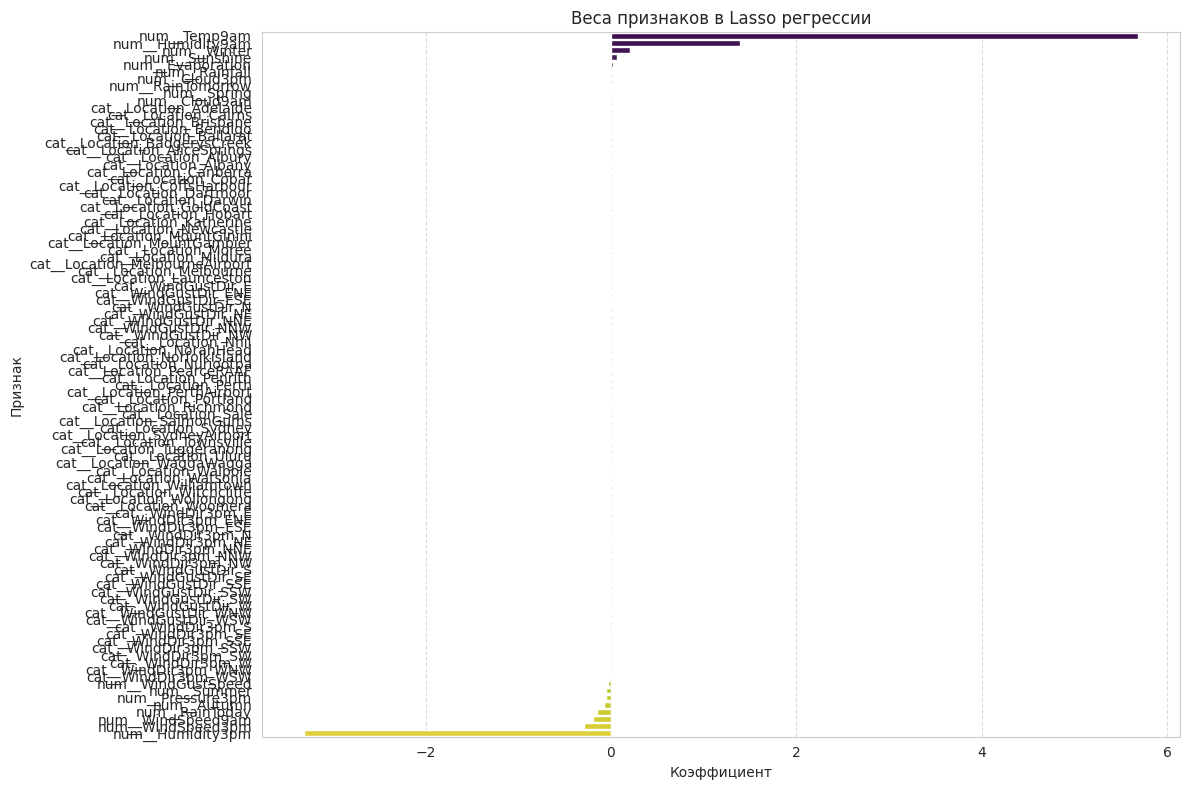

In [35]:
best_lasso_model_pipeline = grid_search_lasso.best_estimator_
best_lasso_model = best_lasso_model_pipeline.named_steps['regr']

lasso_coefficients = best_lasso_model.coef_
feature_names_out = best_lasso_model_pipeline.named_steps['prep'].get_feature_names_out()

coef_df = pd.DataFrame({
    'Feature': feature_names_out,
    'Coefficient': lasso_coefficients
})

coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')
plt.title('Веса признаков в Lasso регрессии')
plt.xlabel('Коэффициент')
plt.ylabel('Признак')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Наиболее значимыми признаками L1 регрессия сочла Temp9am, Humidity9am, Humidity3pm - это легко объяснить физическими соображениями и временным характером этих признаков.  
Интересно, что L1 занулила признаки, отвечающие за времена года осень и весну - это говорит о том, что зимой и летом температуру прогнозировать гораздо проще, чем в переходные сезоны.
Также L1 занулила почти все категориальные признаки.